In [1]:
# Import libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")  # Set a clean visual style

D:\anaconda_jupyter\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\anaconda_jupyter\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
# Load the dataset
df = pd.read_csv(r"D:\Downloads\feature_engineered_dataset.csv")

# Preview first 5 rows
df.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


In [6]:
# Check structure, datatypes, and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4566 entries, 0 to 4565
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   xrCompositeLandUseID     4566 non-null   int64  
 1   xrBuildingTypeID         4566 non-null   float64
 2   LocationStartNumber      4566 non-null   int64  
 3   StreetNameAndWay         4566 non-null   str    
 4   xrPrimaryNeighborhoodID  4566 non-null   int64  
 5   LandSF                   4566 non-null   float64
 6   TotalFinishedArea        4566 non-null   float64
 7   LivingUnits              4566 non-null   float64
 8   OwnerLastName            4566 non-null   str    
 9   SaleDate                 4566 non-null   str    
 10  SalePrice                4566 non-null   float64
 11  TotalAppraisedValue      4566 non-null   int64  
 12  xrSalesValidityID        4566 non-null   int64  
 13  xrDeedID                 4566 non-null   int64  
 14  AssrLandUse              4566 non-n

In [7]:
# Count of missing values in each column
df.isnull().sum()

xrCompositeLandUseID       0
xrBuildingTypeID           0
LocationStartNumber        0
StreetNameAndWay           0
xrPrimaryNeighborhoodID    0
LandSF                     0
TotalFinishedArea          0
LivingUnits                0
OwnerLastName              0
SaleDate                   0
SalePrice                  0
TotalAppraisedValue        0
xrSalesValidityID          0
xrDeedID                   0
AssrLandUse                0
WasZeroPrice               0
LogSalePrice               0
SaleYear                   0
SaleMonth                  0
PricePerSqft               0
AppraisalRatio             0
dtype: int64

In [8]:
# Remove non-informative text columns
df = df.drop(columns=['StreetNameAndWay', 'OwnerLastName'], errors='ignore')

# Convert SaleDate to datetime
df['SaleDate'] = pd.to_datetime(df['SaleDate'])

# Preview updated dataset
df.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,SaleDate,SalePrice,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,2,6000.0,1092.0,1.0,2024-07-01 00:00:00+00:00,259000.0,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,2,6000.0,936.0,1.0,2022-04-26 00:00:00+00:00,208000.0,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,2,6000.0,1111.0,1.0,2023-12-22 00:00:00+00:00,125000.0,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,2,5040.0,1684.0,1.0,2021-01-11 00:00:00+00:00,177000.0,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,2,6000.0,900.0,1.0,2021-09-21 00:00:00+00:00,188000.0,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


In [9]:
# Check statistics to understand ranges, outliers, and central tendency
df.describe()

D:\anaconda_jupyter\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,SalePrice,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
count,4566.000000,4566.00000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4.566000e+03,4.566000e+03,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000
mean,9.583005,10.63272,156.140385,141.702146,7484.303767,2090.640733,1.617608,8.974973e+05,1.790301e+05,10.524748,9.592860,4.880859,12.282204,2022.111476,6.724047,1047.669386,inf
std,45.653560,4.96602,243.700244,100.696498,5048.732722,1396.140708,1.019454,2.372340e+06,1.242587e+05,11.248996,2.564913,1.531215,1.871201,1.130892,3.330640,3253.415981,NaN
min,3.000000,0.00000,1.000000,1.000000,0.000000,371.000000,0.000000,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,2.397895,2020.000000,1.000000,0.002092,0.000028
25%,3.000000,6.00000,37.000000,45.000000,6250.000000,1020.250000,1.000000,1.400000e+05,8.217500e+04,1.000000,10.000000,3.000000,11.849405,2021.000000,4.000000,77.019677,0.980166
50%,5.000000,11.00000,74.000000,151.000000,7000.000000,1748.000000,1.000000,2.300000e+05,1.816500e+05,1.000000,10.000000,5.000000,12.345839,2022.000000,7.000000,108.946632,1.172234
75%,7.000000,16.00000,179.000000,237.000000,7500.000000,3141.600000,2.000000,3.270000e+05,2.405750e+05,25.000000,10.000000,6.000000,12.697719,2023.000000,9.000000,165.901012,1.510045
max,455.000000,30.00000,2706.000000,512.000000,156200.000000,32692.000000,26.000000,1.025014e+07,3.122600e+06,27.000000,19.000000,7.000000,16.142802,2024.000000,12.000000,17982.708772,inf


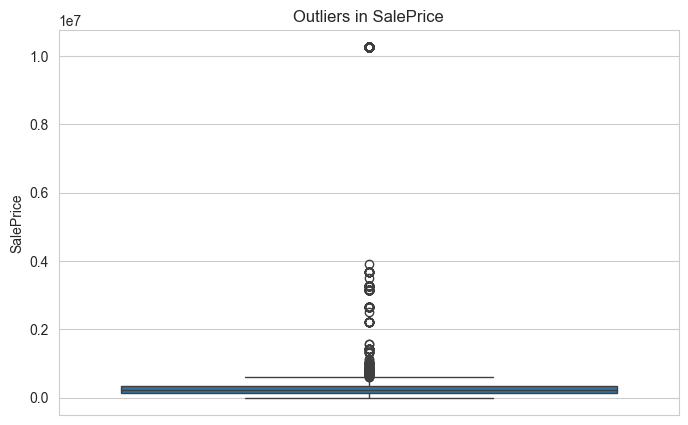

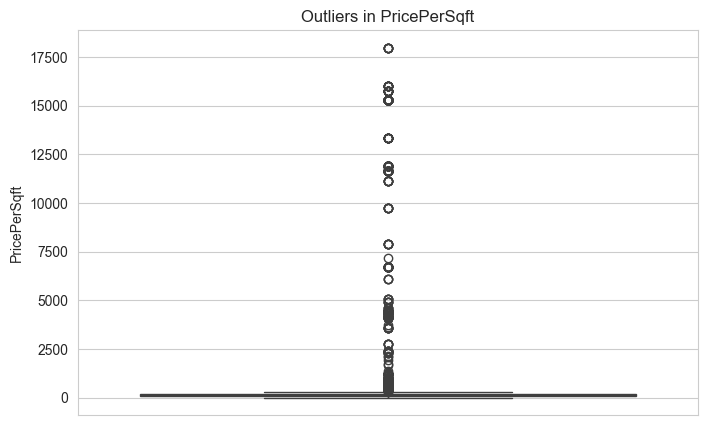

In [10]:
# Boxplot to detect outliers in SalePrice
plt.figure(figsize=(8,5))
sns.boxplot(df['SalePrice'])
plt.title("Outliers in SalePrice")
plt.show()

# Boxplot for PricePerSqft
plt.figure(figsize=(8,5))
sns.boxplot(df['PricePerSqft'])
plt.title("Outliers in PricePerSqft")
plt.show()

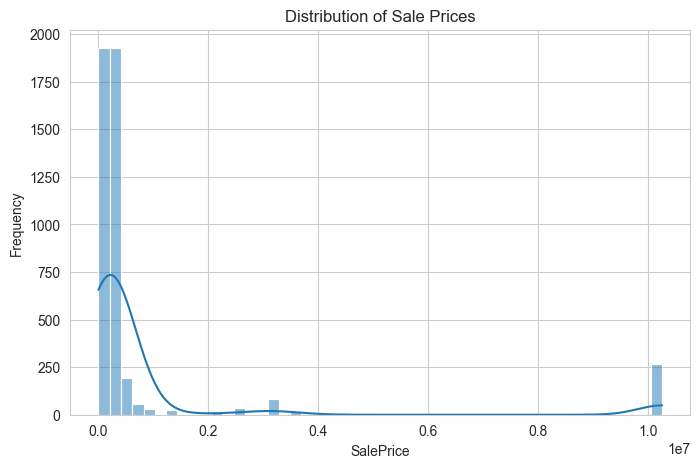

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

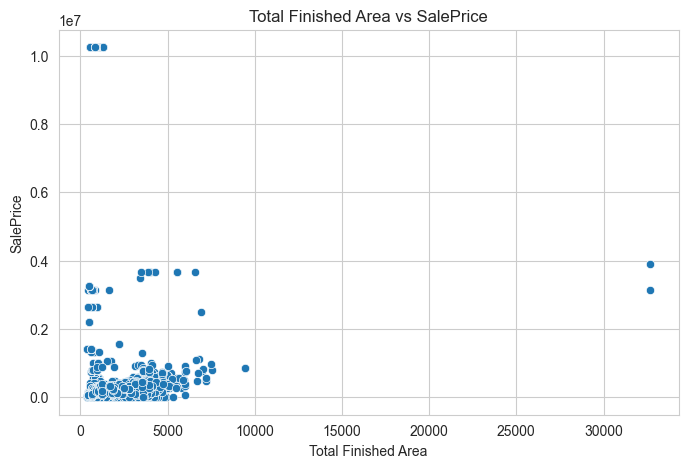

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TotalFinishedArea', y='SalePrice', data=df)
plt.title("Total Finished Area vs SalePrice")
plt.xlabel("Total Finished Area")
plt.ylabel("SalePrice")
plt.show()

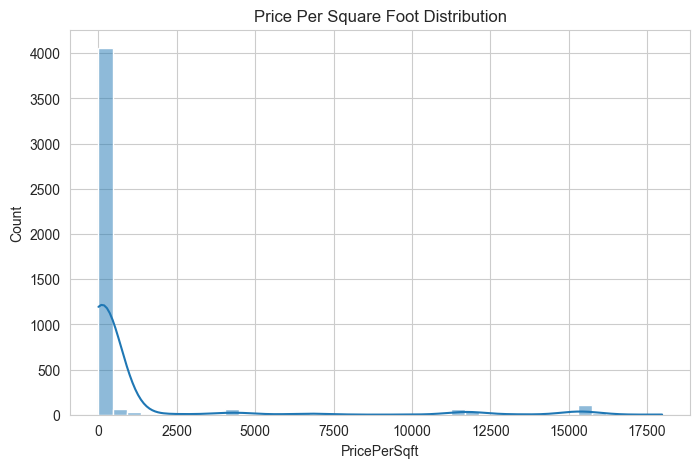

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['PricePerSqft'], bins=40, kde=True)
plt.title("Price Per Square Foot Distribution")
plt.show()

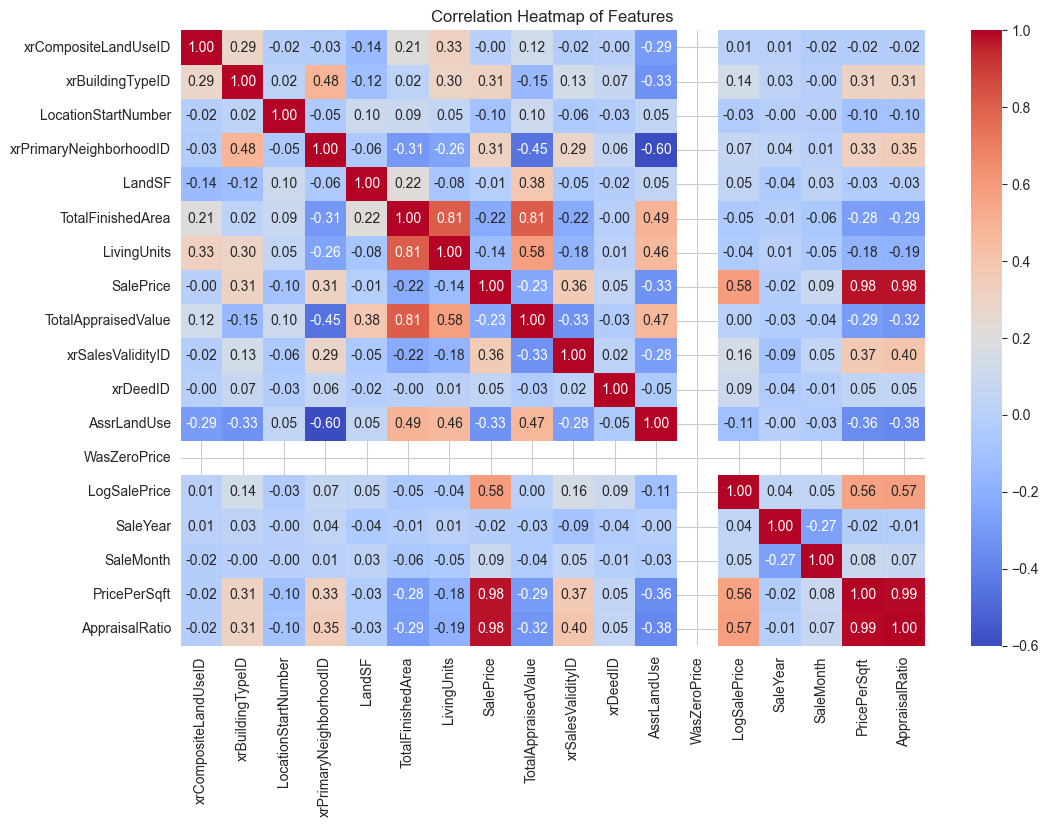

In [14]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

In [15]:
# Extract Year and Month from SaleDate
df['SaleYear'] = df['SaleDate'].dt.year
df['SaleMonth'] = df['SaleDate'].dt.month

# Preview dataset
df.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,SaleDate,SalePrice,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,2,6000.0,1092.0,1.0,2024-07-01 00:00:00+00:00,259000.0,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,2,6000.0,936.0,1.0,2022-04-26 00:00:00+00:00,208000.0,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,2,6000.0,1111.0,1.0,2023-12-22 00:00:00+00:00,125000.0,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,2,5040.0,1684.0,1.0,2021-01-11 00:00:00+00:00,177000.0,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,2,6000.0,900.0,1.0,2021-09-21 00:00:00+00:00,188000.0,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


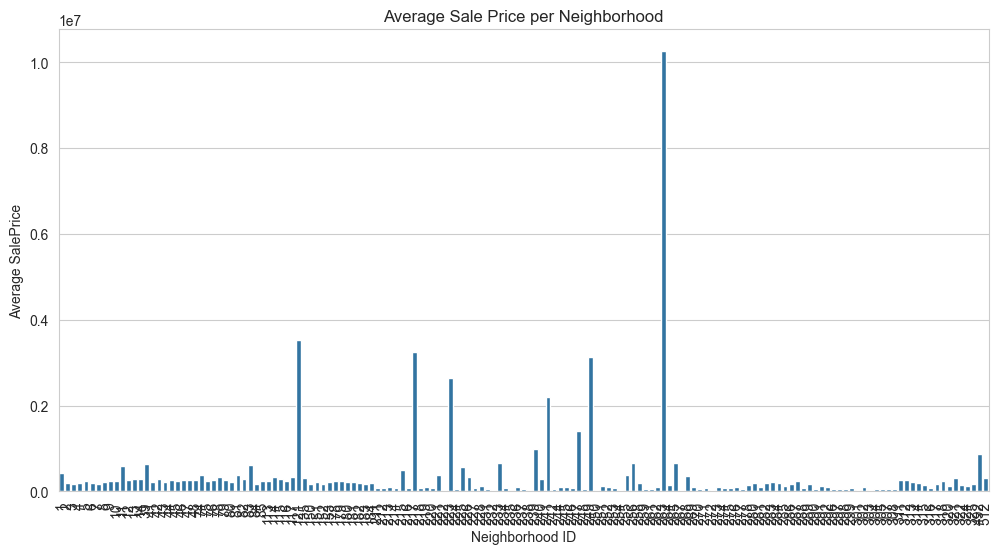

In [16]:
# Average price per neighborhood
avg_price_neighborhood = df.groupby('xrPrimaryNeighborhoodID')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=avg_price_neighborhood.index, y=avg_price_neighborhood.values)
plt.xticks(rotation=90)
plt.title("Average Sale Price per Neighborhood")
plt.ylabel("Average SalePrice")
plt.xlabel("Neighborhood ID")
plt.show()

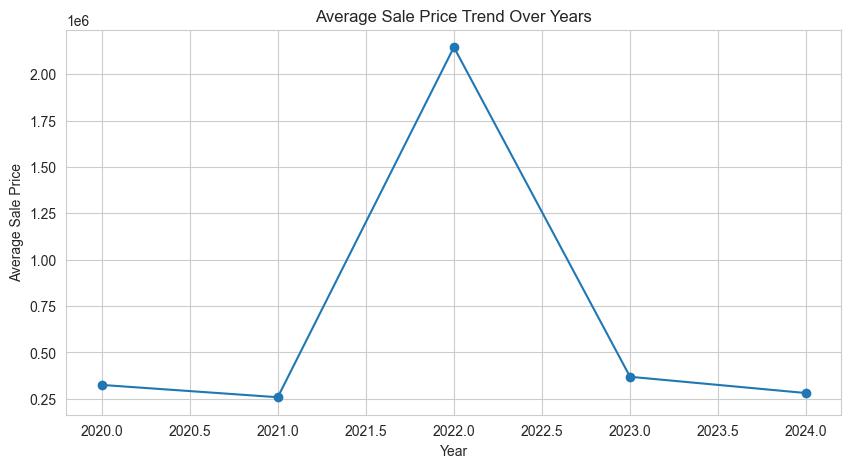

In [17]:
# Price trend per year
price_trend = df.groupby('SaleYear')['SalePrice'].mean()

plt.figure(figsize=(10,5))
price_trend.plot(marker='o')
plt.title("Average Sale Price Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Sale Price")
plt.show()

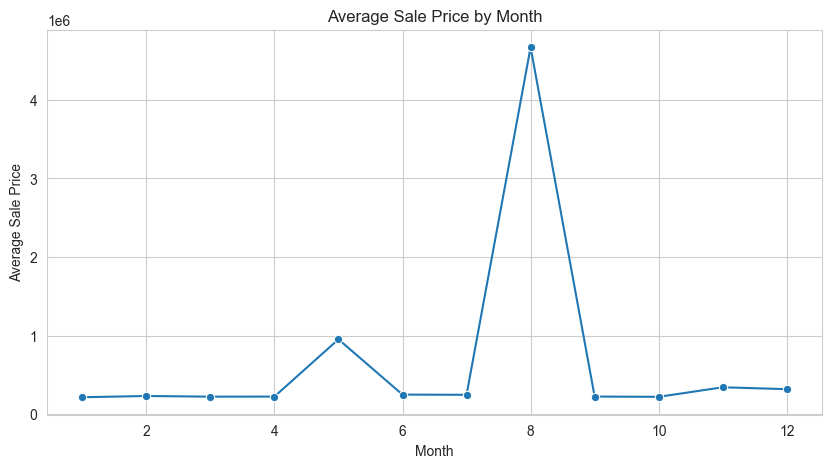

In [18]:
# Monthly price trend
monthly_trend = df.groupby('SaleMonth')['SalePrice'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o')
plt.title("Average Sale Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Sale Price")
plt.show()

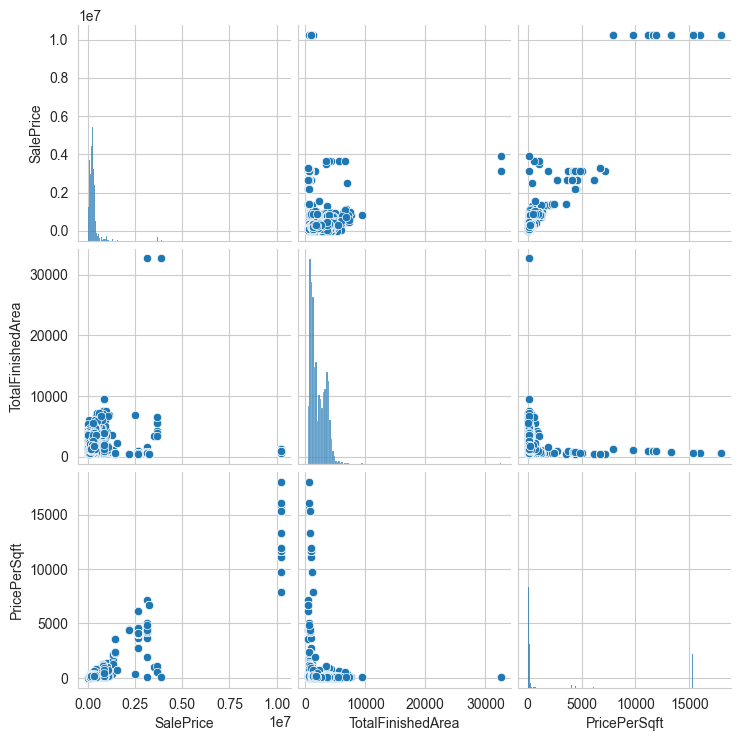

In [20]:
important_cols = ['SalePrice', 'TotalFinishedArea', 'PricePerSqft', 'Bedrooms', 'Bathrooms']
existing_cols = [col for col in important_cols if col in df.columns]
sns.pairplot(df[existing_cols])
plt.show()

In [21]:
# Remove non-predictive columns
features = df.drop(columns=['SalePrice', 'SaleDate'])

# Target variable
target = df['SalePrice']

# Split into train-test sets
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3652, 17)
Testing Data Shape: (914, 17)


In [23]:
# Check for infinite values
print(np.isinf(X_train).sum())  # total infinite values in X_train
print(np.isinf(X_test).sum())

# Check for missing values
print(X_train.isna().sum())
print(X_test.isna().sum())

xrCompositeLandUseID       0
xrBuildingTypeID           0
LocationStartNumber        0
xrPrimaryNeighborhoodID    0
LandSF                     0
TotalFinishedArea          0
LivingUnits                0
TotalAppraisedValue        0
xrSalesValidityID          0
xrDeedID                   0
AssrLandUse                0
WasZeroPrice               0
LogSalePrice               0
SaleYear                   0
SaleMonth                  0
PricePerSqft               0
AppraisalRatio             1
dtype: int64
xrCompositeLandUseID       0
xrBuildingTypeID           0
LocationStartNumber        0
xrPrimaryNeighborhoodID    0
LandSF                     0
TotalFinishedArea          0
LivingUnits                0
TotalAppraisedValue        0
xrSalesValidityID          0
xrDeedID                   0
AssrLandUse                0
WasZeroPrice               0
LogSalePrice               0
SaleYear                   0
SaleMonth                  0
PricePerSqft               0
AppraisalRatio             1
d

In [24]:
# Replace +inf and -inf with NaN, then fill or drop
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
1117,3,5.0,150,46,7500.0,1662.40001,1.0,172800,1,10,5,False,12.345839,2023,11,138.354186,1.331019
416,3,4.0,155,8,7600.0,1107.20001,1.0,166000,12,1,5,False,12.165256,2023,10,173.410403,1.156627
3587,3,4.0,78,151,6250.0,1309.00000,1.0,149400,26,6,5,False,12.206078,2023,9,152.788388,1.338688
2476,7,16.0,16,261,7000.0,600.00000,1.0,38900,1,10,3,False,10.596660,2022,1,66.666667,1.028278
881,4,11.0,259,46,5720.0,3242.40001,2.0,255500,1,10,7,False,12.793862,2023,11,111.028867,1.409002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2473,7,16.0,16,261,7000.0,835.00000,1.0,51600,1,10,3,False,11.134604,2022,6,82.035928,1.327519
4035,5,12.0,11,182,4990.0,2466.75000,3.0,196600,26,10,6,False,12.128117,2022,1,74.997466,0.940997
783,3,6.0,200,12,5625.0,1314.00000,1.0,177900,1,10,5,False,12.358798,2022,11,177.321157,1.309725
4194,4,11.0,58,182,13800.0,1860.00000,2.0,72900,1,10,7,False,11.775297,2023,6,69.892473,1.783265


In [25]:
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_train.mean(), inplace=True)  # Use train mean to avoid data leakage

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
1117,3,5.0,150,46,7500.0,1662.40001,1.0,172800,1,10,5,False,12.345839,2023,11,138.354186,1.331019
416,3,4.0,155,8,7600.0,1107.20001,1.0,166000,12,1,5,False,12.165256,2023,10,173.410403,1.156627
3587,3,4.0,78,151,6250.0,1309.00000,1.0,149400,26,6,5,False,12.206078,2023,9,152.788388,1.338688
2476,7,16.0,16,261,7000.0,600.00000,1.0,38900,1,10,3,False,10.596660,2022,1,66.666667,1.028278
881,4,11.0,259,46,5720.0,3242.40001,2.0,255500,1,10,7,False,12.793862,2023,11,111.028867,1.409002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2473,7,16.0,16,261,7000.0,835.00000,1.0,51600,1,10,3,False,11.134604,2022,6,82.035928,1.327519
4035,5,12.0,11,182,4990.0,2466.75000,3.0,196600,26,10,6,False,12.128117,2022,1,74.997466,0.940997
783,3,6.0,200,12,5625.0,1314.00000,1.0,177900,1,10,5,False,12.358798,2022,11,177.321157,1.309725
4194,4,11.0,58,182,13800.0,1860.00000,2.0,72900,1,10,7,False,11.775297,2023,6,69.892473,1.783265


In [26]:
y_train.replace([np.inf, -np.inf], np.nan, inplace=True)
y_train.fillna(y_train.mean(), inplace=True)

1020      330000.0
2676    10250144.0
229        65000.0
857      3259570.0
1108      215878.0
           ...    
4426      332500.0
466       180000.0
3092      230000.0
3772       66000.0
860      3259570.0
Name: SalePrice, Length: 3652, dtype: float64

In [27]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
pred_gb = gb_model.predict(X_test)

In [28]:
# Function to calculate evaluation metrics
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Evaluate all models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [*evaluate_model(y_test, pred_lr)[:1], *evaluate_model(y_test, pred_rf)[:1], *evaluate_model(y_test, pred_gb)[:1]],
    'RMSE': [*evaluate_model(y_test, pred_lr)[1:2], *evaluate_model(y_test, pred_rf)[1:2], *evaluate_model(y_test, pred_gb)[1:2]],
    'R2 Score': [*evaluate_model(y_test, pred_lr)[2:], *evaluate_model(y_test, pred_rf)[2:], *evaluate_model(y_test, pred_gb)[2:]]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,166856.804479,396823.310966,0.968342
1,Random Forest,3728.790543,89304.230004,0.998397
2,Gradient Boosting,2915.783751,35258.794459,0.999750


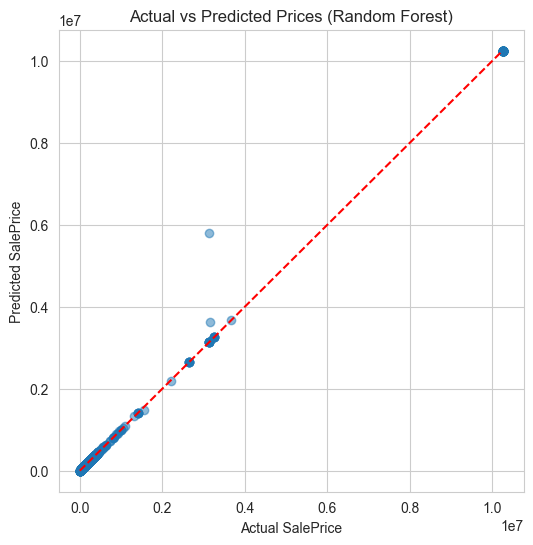

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.show()

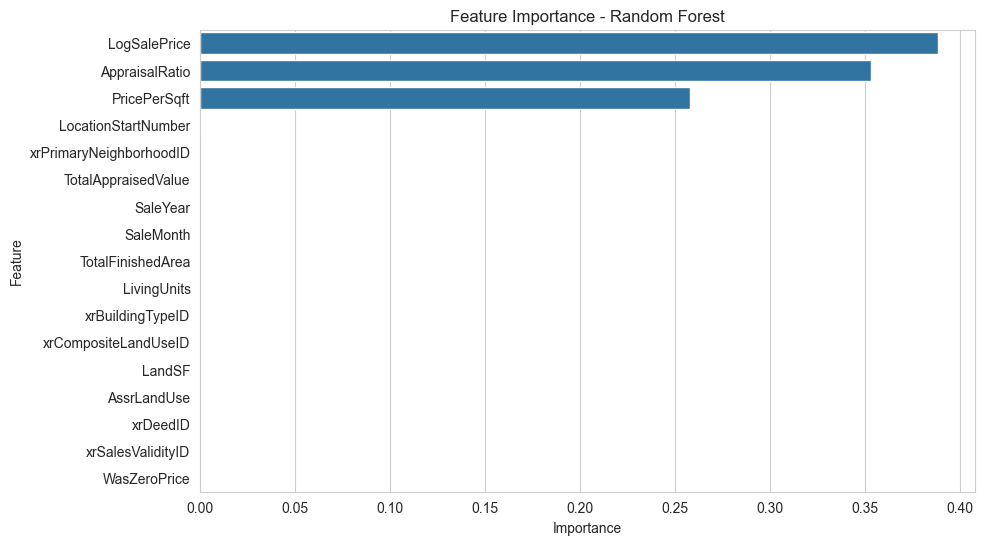

In [30]:
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': features.columns, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance - Random Forest")
plt.show()

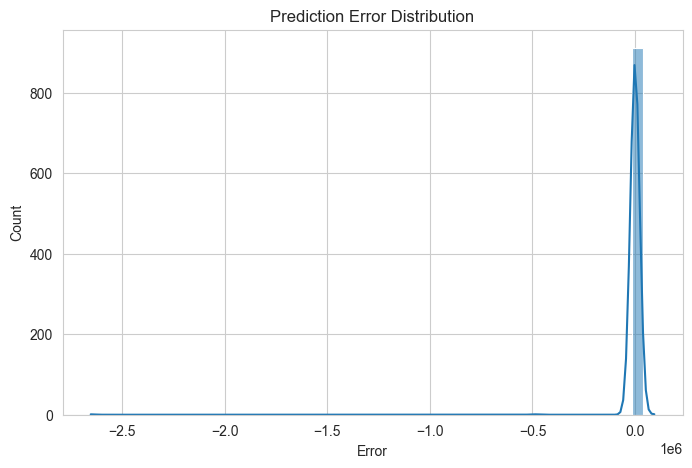

In [31]:
errors = y_test - pred_rf

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=50, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

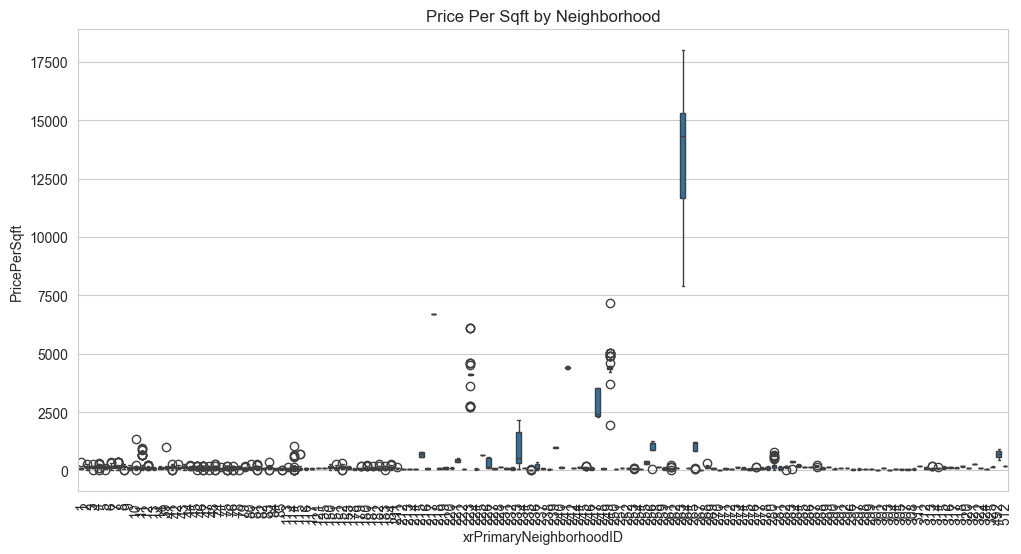

In [32]:
plt.figure(figsize=(12,6))
sns.boxplot(x='xrPrimaryNeighborhoodID', y='PricePerSqft', data=df)
plt.xticks(rotation=90)
plt.title("Price Per Sqft by Neighborhood")
plt.show()

In [38]:
print(df.columns.tolist())

['xrCompositeLandUseID', 'xrBuildingTypeID', 'LocationStartNumber', 'xrPrimaryNeighborhoodID', 'LandSF', 'TotalFinishedArea', 'LivingUnits', 'SaleDate', 'SalePrice', 'TotalAppraisedValue', 'xrSalesValidityID', 'xrDeedID', 'AssrLandUse', 'WasZeroPrice', 'LogSalePrice', 'SaleYear', 'SaleMonth', 'PricePerSqft', 'AppraisalRatio']


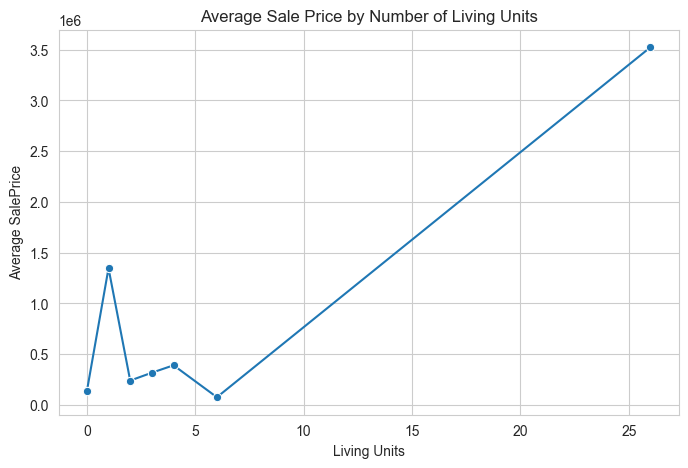

In [40]:
# Clean infinite or missing values
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['LivingUnits', 'SalePrice'])

# Group by LivingUnits and calculate mean SalePrice
livingunit_trend = df_clean.groupby('LivingUnits')['SalePrice'].mean()

# Plot
plt.figure(figsize=(8,5))
sns.lineplot(x=livingunit_trend.index, y=livingunit_trend.values, marker='o')
plt.title("Average Sale Price by Number of Living Units")
plt.xlabel("Living Units")
plt.ylabel("Average SalePrice")
plt.show()

In [41]:
# Display top insights
print("Top 5 Most Important Features (Random Forest):")
print(feat_imp.head())

print("\nBest Model Based on R2 Score:", results.loc[results['R2 Score'].idxmax(), 'Model'])

Top 5 Most Important Features (Random Forest):
                    Feature  Importance
12             LogSalePrice    0.388615
16           AppraisalRatio    0.353248
15             PricePerSqft    0.257837
2       LocationStartNumber    0.000178
3   xrPrimaryNeighborhoodID    0.000030

Best Model Based on R2 Score: Gradient Boosting


In [ ]:
# Export the DataFrame to CSV
df.to_csv('M_dataset.csv', index=False)